In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv('./Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [7]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.shape

(400, 2)

In [10]:
## we will not be using train_test_split because we are using val_split=0.2 which will internally split the train-test in Keras-tensorflow 

# from sklearn.model_selection import train_test_split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
# X_train.shape  #(320,2)

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/Users/kristalshrestha/Documents/Code/DeepLearning_practice/venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Batch Gradient Descent (batch_size = total train datasets/whole datasets if using validation_split)

In [14]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=400,validation_split=0.2)
print(time.time() - start)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.5406 - loss: 0.6901 - val_accuracy: 0.4375 - val_loss: 0.6902
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5969 - loss: 0.6728 - val_accuracy: 0.4500 - val_loss: 0.6902
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6094 - loss: 0.6612 - val_accuracy: 0.4375 - val_loss: 0.6900
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6250 - loss: 0.6520 - val_accuracy: 0.4250 - val_loss: 0.6899
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6313 - loss: 0.6441 - val_accuracy: 0.4250 - val_loss: 0.6897
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6500 - loss: 0.6372 - val_accuracy: 0.4250 - val_loss: 0.6895
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6562 - loss: 0.6309 - val_accuracy: 0.4250 - val_loss: 0.6892
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6594 - loss: 0.6251 - val_accuracy: 0.4250 - val_loss: 0.6890

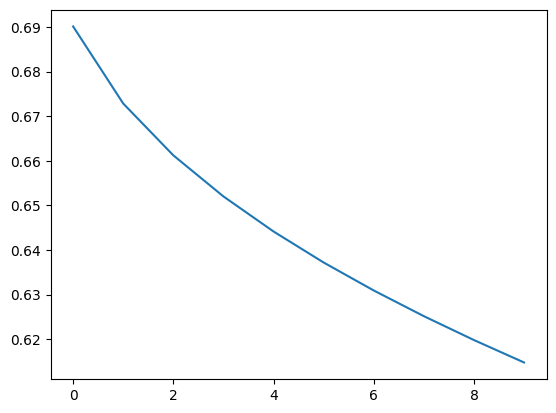

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

## for Stochastic Gradient descent (Batch_size=1 )

In [16]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [17]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=1,validation_split=0.2)
print(time.time() - start)

Epoch 1/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.8375 - loss: 0.4893 - val_accuracy: 0.7375 - val_loss: 0.5856
Epoch 2/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.8656 - loss: 0.3255 - val_accuracy: 0.7625 - val_loss: 0.5047
Epoch 3/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.8562 - loss: 0.2991 - val_accuracy: 0.8250 - val_loss: 0.4063
Epoch 4/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - accuracy: 0.8625 - loss: 0.2847 - val_accuracy: 0.8875 - val_loss: 0.3597
Epoch 5/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.8656 - loss: 0.2786 - val_accuracy: 0.9000 - val_loss: 0.3124
Epoch 6/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.8719 - loss: 0.2709 - val_accuracy: 0.9125 - val_loss: 0.2824
Epoch 7/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step - accuracy: 0.8719 - loss: 0.2728 - val_accuracy: 0.9375 - val_loss: 0.2610
Epoch 8/10
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - accuracy: 0.8750 - loss: 0.2684 - 

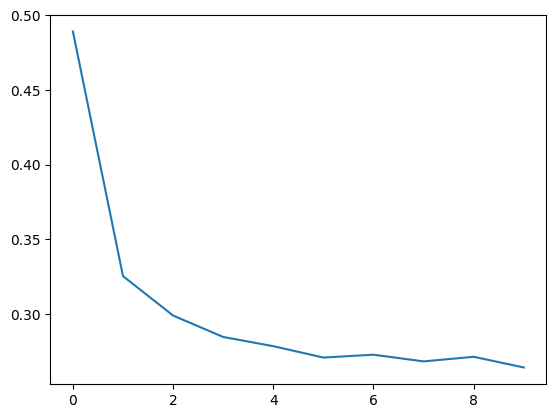

In [18]:
plt.plot(history.history['loss'])